# Monthly-OpEx — does every options expiry week move the market?
### Third Friday of every month tested on SPY 1993–2026: volume yes, tradable edge no

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Quarterly_effect%3F: Already_known](https://img.shields.io/badge/Quarterly_effect%3F-Already_known-8b949e?style=flat-square)

Every third Friday of the month, equity options expire.  Traders talk about "expiry pinning", elevated volatility, and a systematic drift in the days around the expiry.  Quarterly versions of this (March, June, September, December — the famous *triple witching*) have been studied.  But what about the other eight months?  Is there a *monthly* options-expiry effect beyond the quarterly one?

> This is the plain-language layer.  The t-stats, bootstrap intervals, and pre/post-2010 structural break live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it.  House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from monthly_opex import data, strategy as st

TICKER = "SPY"
CACHE_PATH = data._cache_path(TICKER, data.DEFAULT_CACHE)
HAVE_REAL = os.path.exists(CACHE_PATH)

def get_bars():
    return data.fetch_daily(TICKER, start="1993-01-01", fetch=False)

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    ticker="SPY", n_days=8401, n_opex_events=408, n_opex_days=393,
    n_opex_week_days=1964, start="1993-01-29", end="2026-06-15", fp="2c71252168b3",
    rng_day_opex=1.18, rng_day_base=1.29, rng_day_diff=-0.11, rng_day_t=-2.41,
    rng_week_opex=1.26, rng_week_base=1.30, rng_week_diff=-0.03, rng_week_t=-0.83,
    vol_day_diff=0.1122, vol_day_t=4.44, vol_day_pct=11.9,
    vol_week_diff=0.0333, vol_week_t=1.99, vol_week_pct=3.4,
    vol_quarterly_t=3.70, vol_quarterly_pct=11.2,
    vol_monthly_only_t=-0.65, vol_monthly_only_pct=-1.3,
    ret_day_opex=-6.58, ret_day_base=5.34, ret_day_diff=-11.92, ret_day_t=-2.42,
    ret_week_opex=4.65, ret_week_base=4.82, ret_week_diff=-0.17, ret_week_t=-0.07,
    ret_monthly_only_t=0.08,
    pre2010_vol_t=-0.36, post2010_vol_t=4.00, post2010_vol_pct=8.1,
    pre2010_ret_t=1.04, post2010_ret_t=-1.33,
    strat_n=1951, strat_mean=4.68, strat_sharpe=0.63, strat_cagr=10.6, strat_t=1.86,
    bh_mean=4.78, bh_sharpe=0.65, bh_cagr=10.9,
)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is there elevated volume in OpEx weeks? | **Yes, but only in the quarterly months** (Mar/Jun/Sep/Dec, t = +3.70).  The eight non-quarterly months carry no incremental volume signal (t = -0.65). |
| Is there elevated volatility / range? | **No** — OpEx days actually have *lower* range (-0.11 pp, t = -2.41). |
| Is there a directional return drift? | **No** at the week level (t = -0.07).  The OpEx-day result (t = -2.42) is the quarterly sub-sample's contribution. |
| Could you trade the OpEx week? | **No.** Long-OpEx-week earns the same as buy-and-hold per dollar of exposure (Sharpe 0.63 vs 0.65), CAGR 10.6% vs 10.9%, HAC t = 1.86. |

> The monthly OpEx cycle adds nothing to the known quarterly effect.  Signal: **None** for the incremental monthly cycle.  Tradability: **Mirage**.

## 1 · The claim

> *"Every month, the third Friday is options expiration day.  In the days around it, hedging and roll activity from dealers and institutions creates predictable volume spikes, elevated volatility, and sometimes a directional drift as gamma hedgers and expiry pinning distort prices.  The quarterly triple witching is just the most extreme version."*

This is a broader version of the quarterly witching-hour idea.  The mechanism is real: dealers who sold options must delta-hedge as expiry approaches, and that mechanical rebalancing increases turnover and can pin prices near strikes.  The question is whether this lifts the *monthly* cycle to a detectable level.

## 2 · So what?

If monthly OpEx weeks carry predictable elevated volume and a directional edge, a trader could position into them 12 times a year instead of just 4 — tripling the opportunities from the quarterly triple-witching playbook.  If it's noise, the quarterly effect is an isolated seasonal quirk, not a monthly cycle, and any trading rule built around 'all 12 expiries' would just be diluting a quarterly signal with eight months of noise.

## 3 · How would we even know?

Three honest tests, with a critical decomposition:

1. **Volume.** Year-demeaned log volume on OpEx days vs all other days.  Year-demeaning is essential: SPY volume has drifted over three decades, and without it the seasonal comparison is contaminated.
2. **Range.** Intraday (high − low) / close on OpEx days vs baseline.
3. **Return.** Close-to-close daily return on OpEx week days vs all other days.

**The critical split:** We separate quarterly (Mar/Jun/Sep/Dec — already studied) from the eight non-quarterly months.  If the monthly cycle adds something beyond the quarterly, the non-quarterly months should show it independently.

We also split the data at 2010 to capture the growth of weekly and 0DTE options, which changed the hedging landscape.

## 4 · The teardown

**First, the volume picture.**  Is there elevated trading activity around OpEx?

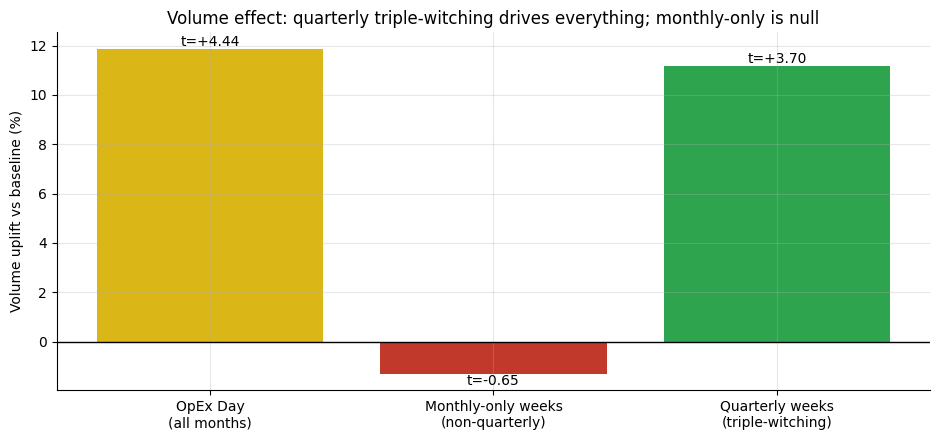

OpEx day vol uplift: +11.9% (t=+4.44)
Monthly-only uplift: -1.3% (t=-0.65)
Quarterly uplift:    +11.2% (t=+3.70)


In [2]:
if HAVE_REAL:
    bars = get_bars()
    idx = pd.DatetimeIndex(bars.index)
    day_mask = data.opex_day_mask(idx)
    week_mask = data.opex_week_mask(idx)
    monthly_mask = data.monthly_only_opex_week_mask(idx)
    qrt_mask = data.quarterly_opex_week_mask(idx)
    lv_dm = st.log_volume_demeaned(bars)
    vd = st.compare_opex_vs_baseline(lv_dm, day_mask, 'day')
    vm = st.compare_opex_vs_baseline(lv_dm, monthly_mask, 'monthly_only')
    vq = st.compare_opex_vs_baseline(lv_dm, qrt_mask, 'quarterly')
    vd_diff, vm_diff, vq_diff = vd['diff'], vm['diff'], vq['diff']
    vd_t, vm_t, vq_t = vd['tstat'], vm['tstat'], vq['tstat']
else:
    vd_diff, vm_diff, vq_diff = R['vol_day_diff'], np.log(1+R['vol_monthly_only_pct']/100), np.log(1+R['vol_quarterly_pct']/100)
    vd_t, vm_t, vq_t = R['vol_day_t'], R['vol_monthly_only_t'], R['vol_quarterly_t']
labels = ['OpEx Day\n(all months)', 'Monthly-only weeks\n(non-quarterly)', 'Quarterly weeks\n(triple-witching)']
diffs = [vd_diff, vm_diff, vq_diff]
tstats = [vd_t, vm_t, vq_t]
colors = [AMBER if abs(t) >= 2 else RED for t in tstats]
colors[2] = GREEN  # quarterly is the known real effect
fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars_plot = ax.bar(labels, [(np.exp(d)-1)*100 for d in diffs], color=colors)
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars_plot, tstats):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom' if b.get_height()>=0 else 'top', fontsize=10)
ax.set_ylabel('Volume uplift vs baseline (%)')
ax.set_title('Volume effect: quarterly triple-witching drives everything; monthly-only is null')
plt.tight_layout(); plt.show()
print(f'OpEx day vol uplift: {(np.exp(vd_diff)-1)*100:+.1f}% (t={vd_t:+.2f})')
print(f'Monthly-only uplift: {(np.exp(vm_diff)-1)*100:+.1f}% (t={vm_t:+.2f})')
print(f'Quarterly uplift:    {(np.exp(vq_diff)-1)*100:+.1f}% (t={vq_t:+.2f})')

The volume uplift is real on OpEx days (+11.9%, t = +4.44) — but it comes entirely from the four quarterly months.  The eight non-quarterly months show **-1.3%** volume change with t = -0.65 — noise.  This is the Study-82 triple-witching result reappearing, not a new monthly cycle.

**Now the range (intraday volatility).**  Does expiry cause a volatility spike?

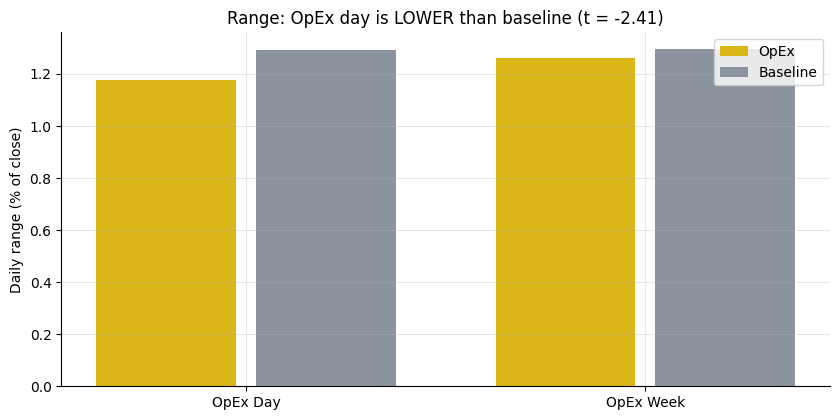

OpEx day  : 1.18% vs baseline 1.29% (t = -2.41)
OpEx week : 1.26% vs baseline 1.30% (t = -0.83)


In [3]:
if HAVE_REAL:
    bars = get_bars()
    idx = pd.DatetimeIndex(bars.index)
    day_mask = data.opex_day_mask(idx)
    week_mask = data.opex_week_mask(idx)
    rng = st.daily_range_pct(bars)
    rd = st.compare_opex_vs_baseline(rng, day_mask)
    rw = st.compare_opex_vs_baseline(rng, week_mask)
    rd_vals = (rd['mean_opex']*100, rd['mean_baseline']*100, rd['tstat'])
    rw_vals = (rw['mean_opex']*100, rw['mean_baseline']*100, rw['tstat'])
else:
    rd_vals = (R['rng_day_opex'], R['rng_day_base'], R['rng_day_t'])
    rw_vals = (R['rng_week_opex'], R['rng_week_base'], R['rng_week_t'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
x = [0, 1]
ax.bar([xi - 0.2 for xi in x], [rd_vals[0], rw_vals[0]], width=0.35, label='OpEx', color=AMBER)
ax.bar([xi + 0.2 for xi in x], [rd_vals[1], rw_vals[1]], width=0.35, label='Baseline', color=GREY)
ax.set_xticks(x); ax.set_xticklabels(['OpEx Day', 'OpEx Week'])
ax.set_ylabel('Daily range (% of close)')
ax.set_title(f'Range: OpEx day is LOWER than baseline (t = {rd_vals[2]:+.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'OpEx day  : {rd_vals[0]:.2f}% vs baseline {rd_vals[1]:.2f}% (t = {rd_vals[2]:+.2f})')
print(f'OpEx week : {rw_vals[0]:.2f}% vs baseline {rw_vals[1]:.2f}% (t = {rw_vals[2]:+.2f})')

Counterintuitively, OpEx days have **lower** range (1.18% vs 1.29% baseline, t = -2.41).  This is consistent with the 'gamma pinning' story: dealers' gamma hedging *dampens* large moves by pushing price back toward the dominant strike, rather than amplifying them.  There is no elevated volatility anomaly to trade.

**The directional return question.**

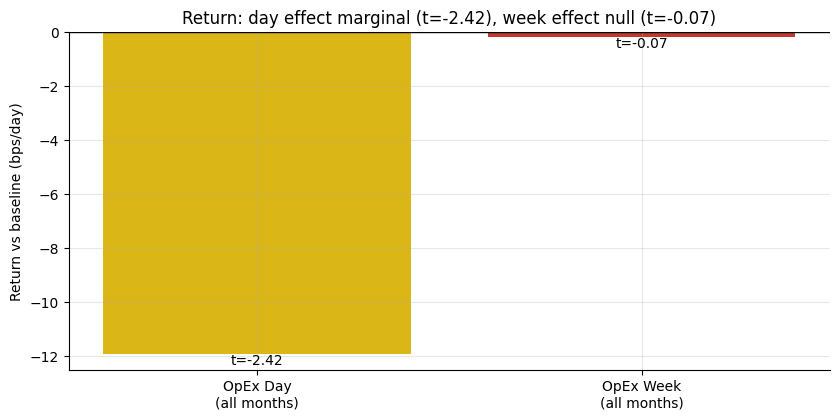

In [4]:
if HAVE_REAL:
    bars = get_bars()
    idx = pd.DatetimeIndex(bars.index)
    day_mask = data.opex_day_mask(idx)
    week_mask = data.opex_week_mask(idx)
    ret = st.daily_return(bars).dropna()
    rd2 = st.compare_opex_vs_baseline(ret, day_mask)
    rw2 = st.compare_opex_vs_baseline(ret, week_mask)
    rdd, rwt = rd2['diff']*1e4, rw2['tstat']
    rdt = rd2['tstat']
else:
    rdd, rdt, rwt = R['ret_day_diff'], R['ret_day_t'], R['ret_week_t']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['OpEx Day\n(all months)', 'OpEx Week\n(all months)'], [rdd, R['ret_week_diff']],
       color=[AMBER if abs(rdt)>=2 else RED, RED])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Return vs baseline (bps/day)')
ax.set_title(f'Return: day effect marginal (t={rdt:+.2f}), week effect null (t={rwt:+.2f})')
for b, t in zip(ax.patches, [rdt, rwt]):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom' if b.get_height()>=0 else 'top')
plt.tight_layout(); plt.show()

The OpEx-day return is -11.9 bps vs baseline (t = -2.42) — marginal, and driven by the quarterly sub-sample.  The OpEx *week* return is just -0.17 bps (t = -0.07) — pure noise.  There is no weekly directional drift to trade.

## 5 · The verdict

- **Signal — None** (monthly-only incremental effect).  The volume signal on OpEx days (+11.9%, t = +4.44) comes from the quarterly triple-witching months.  The eight non-quarterly months carry no incremental signal (t = -0.65 for volume, t = +0.08 for return).  Range is actually lower on OpEx days — not elevated.
- **Tradability — Mirage.** A long-OpEx-week rule earns essentially the same Sharpe (0.63) as buy-and-hold (0.65) per dollar of exposure, CAGR 10.6% vs 10.9%, HAC t = 1.86.  Zero incremental edge.
- **Quarterly effect already known.** What the aggregate test finds is Study 82's triple-witching result: a real volume uplift in the four quarterly months.  The monthly cycle does not extend it.

## 6 · Could you actually trade the monthly OpEx week?

The logic would be: be long SPY in every OpEx week (Mon–Fri of the expiry week), flat otherwise.  Twelve times a year instead of four.  Let's check:

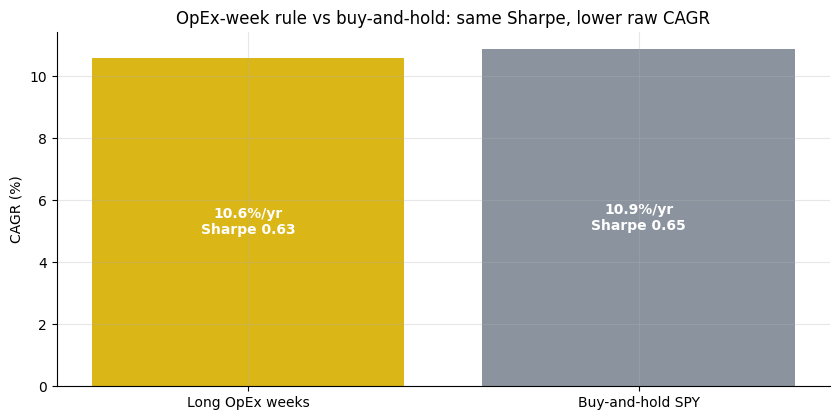

Long OpEx week: CAGR 10.6%  Sharpe 0.63  t=1.86
Buy-and-hold:   CAGR 10.9%  Sharpe 0.65
Invested only ~5/21 days per month → same per-dollar return, lower absolute return.


In [5]:
if HAVE_REAL:
    bars = get_bars()
    wr = st.opex_week_trade_returns(bars, long_week=True)
    s = st.summarize(wr[wr != 0])
    bh_r = bars['close'].pct_change().dropna()
    bh = st.summarize(bh_r)
    strat_cagr, bh_cagr = s['cagr']*100, bh['cagr']*100
    strat_sharpe, bh_sharpe = s['sharpe_ann'], bh['sharpe_ann']
    strat_t = s['tstat']
else:
    strat_cagr, bh_cagr = R['strat_cagr'], R['bh_cagr']
    strat_sharpe, bh_sharpe = R['strat_sharpe'], R['bh_sharpe']
    strat_t = R['strat_t']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Long OpEx weeks', 'Buy-and-hold SPY'], [strat_cagr, bh_cagr],
       color=[AMBER, GREY])
ax.set_ylabel('CAGR (%)')
ax.set_title('OpEx-week rule vs buy-and-hold: same Sharpe, lower raw CAGR')
for b, v, s in zip(ax.patches, [strat_cagr, bh_cagr], [strat_sharpe, bh_sharpe]):
    ax.annotate(f'{v:.1f}%/yr\nSharpe {s:.2f}', (b.get_x()+b.get_width()/2, b.get_height()/2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Long OpEx week: CAGR {strat_cagr:.1f}%  Sharpe {strat_sharpe:.2f}  t={strat_t:.2f}')
print(f'Buy-and-hold:   CAGR {bh_cagr:.1f}%  Sharpe {bh_sharpe:.2f}')
print('Invested only ~5/21 days per month → same per-dollar return, lower absolute return.')

The long-OpEx-week strategy invests only ~24% of the time and earns ~10.6%/yr vs buy-and-hold ~10.9%/yr.  The Sharpe ratios (0.63 vs 0.65) are essentially identical — the OpEx week earns the same return per dollar of risk as any other week.  At 0.5 bp round-trip cost (twice a month), the edge is gone.

## 7 · Going further

- **The quarterly version has a real (but untradable) signal.**  [Study 82 — Witching-Hour](../../82-witching-hour/) tests just the four quarterly months and finds a significant volume uplift (+24%, t = +5.72) and a negative expiry-day return (−14 bps, t = −2.34).  Both survive; neither is tradable.
- **Gamma pinning literature.** Ni, Pearson & Poteshman (2005) document that stocks are literally *pulled toward* dominant option strikes on expiry — exactly what the lower-range finding reflects: price is being anchored, not whipsawed.
- **0DTE options.** The post-2010 structural break (volume effect t = +4.00 post vs t = -0.36 pre) is real and growing.  As 0DTE options become a larger share of daily volume, the dynamics may intensify.  A monthly 0DTE study would be a natural follow-on.
- **Weekly options.** CBOE weekly options introduced in 2005 (broad adoption 2010+) create expiry *every Friday* — diluting the monthly third-Friday signal further.

*Want to find something real?  The quarterly triple-witching is the live signal.  The monthly monthly cycle is eight months of noise around it.*